# MADS 502: Math Methods for Data Science 


# School of Information, University of Michigan


## Week 4: CLT, Hypothesis Testing, and Regressions

In this assignment, you will use Matplotlib to explore the CLT, scipy.stats to perform hypothesis testings, and Statsmodels to run some linear and logistic regressions. Please read the directions carefully to avoid submitting answers that are marked incorrect due to formatting mistakes.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

import statsmodels.api as sm

from mads.lib.path import assets

The dataset that you will use in this assignment is about New York taxi rides between 2010 and 2013. You will focus on the effect of default tip suggestions on tipping behavior as in Hoover, H. (2022). Nudges as norms: Evidence from the NYC taxi cab industry. Journal of Economic Psychology, 92, 102535. The full dataset is available online: Donovan, Brian; Work, Dan (2016): New York City Taxi Trip Data (2010–2013). University of Illinois at Urbana-Champaign. https://doi.org/10.13012/J8PN93H8.

Here is the relevant history from Hoover's paper: "All taxi cabs were outfitted with the new technologies of which a majority were supplied by Creative Mobile Technologies (CMT) and Verifone (VTS). [...] While both companies offered an array of suggested tips on the payment screen, the amounts suggested and their presentation varied. Verifone [...] suggested tips of 20, 25, and 30 percent for fares over $15. CMT suggested tips of 15, 20, and 25 percent for all fare amounts. [...] On February 9th 2011, CMT changed their default options from 15, 20, and 25 percent to 20, 25, and 30 percent, respectively."

You will consider only fares over $\$15$ and you will explore the effect of CMT increasing each of their default tip suggestions by 5%. The dataset has already been filtered to only include fares over $15. Also, in the dataset, the variable post_feb is equal to 1 if the date of the ride was after February 9, 2011, and otherwise it is equal to 0.

In [2]:
#let's read the dataset into a pandas dataframe
file = assets.find("taxi.csv")
taxi = pd.read_csv(file)

In [3]:
#let's look at the column names and the first few values for each column
taxi.head()

,vendor_id,VTS,CMT,passenger_count,total_amount,tip_amount,tip_percentage,post_feb,CMTxpost,default_option,zero_tip,trip_time_in_minutes,trip_distance,airport
0,CMT,0,1,1,55.299999,0.00,0.00,1,1,0,1,23.800000,15.20,0
1,CMT,0,1,2,60.080002,10.01,19.99,0,0,1,0,9.466667,0.90,0
2,VTS,1,0,2,52.070000,2.00,4.44,0,0,0,0,27.000000,18.15,1
3,CMT,0,1,1,62.580002,12.51,24.99,0,0,1,0,30.083333,17.40,1
4,VTS,1,0,1,50.000000,4.50,10.00,1,0,0,0,27.000000,18.08,0


In [4]:
#let's learn a little bit about each of the variables
taxi.describe()

,VTS,CMT,passenger_count,total_amount,tip_amount,tip_percentage,post_feb,CMTxpost,default_option,zero_tip,trip_time_in_minutes,trip_distance,airport
count,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000,64157.000000
mean,0.544804,0.455196,1.642549,59.997576,8.253887,16.934018,0.538304,0.253488,0.512041,0.070764,37.676830,16.660998,0.418614
std,0.497992,0.497992,1.242081,13.495986,4.589421,8.994950,0.498534,0.435011,0.499859,0.256432,16.167452,5.484677,0.493336
min,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033333,0.010000,0.000000
25%,0.000000,0.000000,1.000000,54.599998,5.500000,11.110000,0.000000,0.000000,0.000000,0.000000,27.900000,16.500000,0.000000
50%,1.000000,0.000000,1.000000,58.299999,9.000000,19.990000,1.000000,0.000000,1.000000,0.000000,36.000000,17.700001,0.000000
75%,1.000000,1.000000,2.000000,60.360001,10.060000,20.000000,1.000000,1.000000,1.000000,0.000000,47.000000,19.000000,1.000000
max,1.000000,1.000000,6.000000,361.600010,150.000000,414.290010,1.000000,1.000000,1.000000,1.000000,178.016667,85.400002,1.000000


## Part A: The Central Limit Theorem

<strong>A1</strong> \[1 pt\] Consider the population of interest to be all taxi rides taken in New York City between 2010 and 2013. The taxi rides in the dataset are a sample of the taxi rides in the population. How many observations are in the sample? Store your answers in the variable <strong>sample_size</strong> as an int.

In [5]:
sample_size = None

# YOUR CODE HERE
sample_size = len(taxi)
sample_size

64157

In [6]:
#Hidden tests for Question A1 are within this cell.

<strong>A2</strong> \[1 pt\] What is the sample mean of tip percentage? What is the sample variance of tip percentage? Given the sample size and the sample variance, what is the standard error of the sample mean of tip percentages? 

Remember to set the ddof parameter to take in account the fact that the sample variance is calculated with the sample mean instead of the population mean.

In [7]:
tip_percentages = np.array(taxi['tip_percentage'])
sample_mean = None
sample_var = None
standard_error = None

# YOUR CODE HERE
sample_mean = np.mean(tip_percentages)
sample_var = np.var(tip_percentages, ddof=1)
standard_error = np.sqrt(sample_var / len(tip_percentages))

standard_error

np.float64(0.0355121317616593)

In [8]:
#Hidden tests for Question A2 are within this cell.

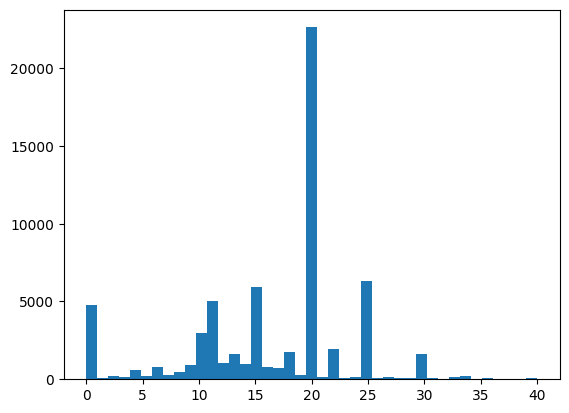

In [9]:
#let's look at the distribution of tip percentages.
plt.hist(tip_percentages, bins= 41, range=(0,40))
plt.show()

#It looks a little bit symmetric but not especially normal (e.g. there are a few huge spikes).

<strong>A3</strong> \[2 pt\] Let's pretend that the distribution of tip percentages in the population is the same as the distribution of tip percentages in our sample. In reality, we won't know the distribution of tip percentages in the population. All we have is our $N$ observations that comprise our sample. We are just pretending in order to see the CLT at work.

Use np.random.choice( ) with the "size" parameter set to sample_size to draw a new random sample from the tip_percentages variable. Find the mean tip percentage and record it in a list called <strong>random_sample_means</strong>. Repeat this process until random_sample_means has 1000 elements. Then make a histogram with 25 bins of the distribution of the random sample means. Just use the defaults for all other parameters when making your histogram.

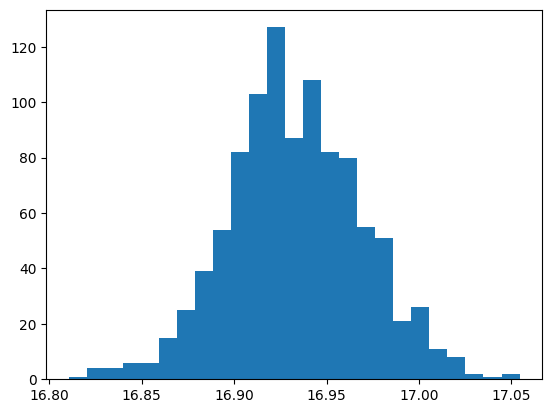

In [10]:
random_sample_means= []

# YOUR CODE HERE
for _ in range(1000):
     sample = np.random.choice(tip_percentages, size=sample_size, replace=True)
     random_sample_means.append(np.mean(sample))

plt.hist(random_sample_means, bins= 25)
plt.show()

In [11]:
#Hidden tests for Question A3 are within this cell.

## Part B: Hypothesis Testing and Confidence Intervals

<strong>B1</strong> \[2 pt\] Let's hypothesize that the mean tip percentage in the population is 17%. Use  sample_mean, standard_error, and the hypothesized value to calculate the t-statistic. Then use scipy.stats's norm.cdf function to calculate the p-value. Finally, decide whether you reject or fail to reject the hypothesis. Store your answers in the variables <strong>t_stat</strong>, <strong>p_val</strong>, and <strong>reject_or_not</strong>. The variable reject_or_not should either be the string "reject" or the string "fail to reject". Remember to look at the units of the variable tip_percentage (in the output of taxi.head() above) in order to set the hypothesized value correctly. 

In [12]:
print(sample_mean, standard_error)

16.934017942783438 0.0355121317616593


In [13]:
t_stat = None
p_val = None
reject_or_not = None
# YOUR CODE HERE
t_stat = (sample_mean - 17) / standard_error
p_val = 2 * norm.cdf(t_stat)
reject_or_not = 'fail to reject'

In [14]:
#Hidden tests for Question B1 are within this cell.

<strong>B2</strong> \[1 pt\] Let's do a slightly different hypothesis test and let's do it in one step. Use the ttest_1samp function to test the hypothesis that the mean tip percentage in the population is 17.1%. Store the results of the ttest_1samp function in the variable <strong>hypo_results</strong>. Use hypo_results and an if-else structure to define the variable <strong>reject_or_not</strong>. Again, the variable reject_or_not should either be the string 'reject' or the string 'fail to reject'.

In [15]:
hypo_results = None
reject_or_not = None

# YOUR CODE HERE
hypo_results = ttest_1samp(tip_percentages, popmean = 17.1)
print(hypo_results.pvalue)
reject_or_not = 'reject'

2.96055459899902e-06


In [16]:
#Hidden tests for Question B2 are within this cell.

<strong>B3</strong> \[1 pt\] Make a $99\%$ confidence interval for the mean tip percentage in the population. Store your answer in the variable <strong>CI</strong> as a numpy array.

In [17]:
CI = None

# YOUR CODE HERE
lower, upper = norm.interval(0.99, loc=sample_mean, scale=standard_error)
CI = np.array([lower, upper])
CI

array([16.84254475, 17.02549113])

In [18]:
#Hidden tests for Question B3 are within this cell.

In [19]:
#let's make some variables to use over the next two questions.
pre_feb_taxi = taxi.loc[taxi['post_feb'].isin([0])]
pre_feb_CMT_tip_percent = np.array(pre_feb_taxi.loc[pre_feb_taxi['vendor_id'].isin(["CMT"])]['tip_percentage'])
pre_feb_VTS_tip_percent = np.array(pre_feb_taxi.loc[pre_feb_taxi['vendor_id'].isin(["VTS"])]['tip_percentage'])

post_feb_taxi = taxi.loc[taxi['post_feb'].isin([1])]
post_feb_CMT_tip_percent = np.array(post_feb_taxi.loc[post_feb_taxi['vendor_id'].isin(["CMT"])]['tip_percentage'])
post_feb_VTS_tip_percent = np.array(post_feb_taxi.loc[post_feb_taxi['vendor_id'].isin(["VTS"])]['tip_percentage'])

<strong>B4</strong> \[2 pt\] Remember that, prior to February 9, 2011, CMT's default tip suggestions were 15, 20, and 25 percent wheras VTS's default tip suggestions were 20, 25, and 30 percent. Use scipy.stat's ttest_ind function to test the hypothesis that the pre-February 9, 2011, tip percentage was the same for taxis with CMT and taxis with VTS. Store your t-statistic, p-value, and decision about whether to reject or fail to reject in the variables <strong>t_stat</strong>, <strong>p_val</strong>, and <strong>reject_or_not</strong>.

In [20]:
t_stat = None
p_val = None
reject_or_not = None

# YOUR CODE HERE
B4_Hype_Results = ttest_ind(pre_feb_CMT_tip_percent, pre_feb_VTS_tip_percent)
print(B4_Hype_Results)

t_stat = B4_Hype_Results.statistic
p_val = B4_Hype_Results.pvalue
reject_or_not = 'reject'

TtestResult(statistic=np.float64(-10.487969895242951), pvalue=np.float64(1.0883652760398254e-25), df=np.float64(29619.0))


In [21]:
#Hidden tests for Question B4 are within this cell.

<strong>B5</strong> \[1 pt\] Remember that, after February 9, 2011, both CMT's and VTS's default tip suggestions were 20, 25, and 30 percent. Use scipy.stat's ttest_ind function to test the hypothesis that the post-February 9, 2011, tip percentage was the same for taxis with CMT and taxis with VTS. Store your t-statistic, p-value, and decision about whether to reject or fail to reject in the variables <strong>t_stat</strong>, <strong>p_val</strong>, and <strong>reject_or_not</strong>.

In [22]:
t_stat = None
p_val = None
reject_or_not = None

# YOUR CODE HERE
B5_Hype_Results = ttest_ind(post_feb_CMT_tip_percent, post_feb_VTS_tip_percent)
print(B5_Hype_Results)

t_stat = B5_Hype_Results.statistic
p_val = B5_Hype_Results.pvalue
reject_or_not = 'fail to reject'

TtestResult(statistic=np.float64(-1.0788391633758283), pvalue=np.float64(0.28066696795748214), df=np.float64(34534.0))


In [23]:
#Hidden tests for Question B5 are within this cell.

## Part C: Linear Regressions

<strong>C1</strong> \[2 pt\] Create a new dataframe called CMT_taxi that is the taxi dataframe but with only the observations in which the vendor_id is CMT. As an example, the dataframe pre_feb_taxi (created earlier in this assignment) is the taxi dataframe but with only the observations in which post_feb is 0. With the CMT_taxi dataframe, consider the OLS regression in which the dependent variable is tip_percentage and the independent variable is post_feb. Make a variable X that is a numpy array of the independent variable, then add a constant term to it. Make a variable y that is a numpy array of the dependent variable. As an example of how to make a numpy array from a column in a dataframe, look at how the variable tip_percentages was made for Question A2 above.

Now use X, y, and matrix multiplication to obtain the OLS coefficients-- the betas. Then use X, the betas, and matrix multiplication to obtain the predicted value for each of the observations. Store these answers as the variables <strong>betas</strong> and <strong>predicted_vals</strong> as numpy arrays.

In [24]:
CMT_taxi = None
X = None
y = None
betas = None
predicted_vals = None

# YOUR CODE HERE
CMT_taxi = taxi.loc[taxi['vendor_id'] == 'CMT']
#CMT_taxi.head()
X = np.array(CMT_taxi['post_feb'])
y = np.array(CMT_taxi['tip_percentage'])
print(X.shape)
print(y.shape)
#corr = np.round(np.corrcoef(X, y), 2)
#print(corr)
X = sm.add_constant(X)

betas = np.linalg.inv(X.T @ X) @ X.T @ y
predicted_vals = X @ betas

(29204,)
(29204,)


In [25]:
#Hidden tests for Question C1 are within this cell.

<strong>C2</strong> \[2 pt\] Run the same OLS regression but with two differences: (a) do not turn your X or y variables into numpy arrays, just leave them as columns from a dataframe, and (b) use statsmodels to run and fit the OLS model with cov_type HC3. Store the results in a variable OLS_results and print the summary. Store the params attribute and the bse attribute in the variables <strong>coeffs</strong> and <strong>std_errors</strong>. Is the variable post_feb statistically significant? Store the answer in the variable <strong>stat_sig</strong> as either the string "yes" or "no".

In [26]:
X = None
y = None
OLS_results = None
coeffs = None
std_errors = None
stat_sig = None
# YOUR CODE HERE
X = CMT_taxi['post_feb']
y = CMT_taxi['tip_percentage']
X = sm.add_constant(X)
OLS_results = sm.OLS(y, X).fit(cov_type='HC3')
print(OLS_results.summary())

coeffs = OLS_results.params
std_errors = OLS_results.bse
print(coeffs, std_errors)
stat_sig = 'yes'

                            OLS Regression Results                            
Dep. Variable:         tip_percentage   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     199.7
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           3.39e-45
Time:                        02:09:31   Log-Likelihood:            -1.0300e+05
No. Observations:               29204   AIC:                         2.060e+05
Df Residuals:                   29202   BIC:                         2.060e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.8991      0.068    234.528      0.0

In [27]:
#Hidden tests for Question C2 are within this cell.

<strong>C3</strong> \[3 pt\] It seems like taxi's with CMT displays had greater tip percentages after February 9, 2011, than they did before. This might be because CMT increased their default tip suggestions, but it also might be the case that tip percentages just increase over time. One way to try to understand which of these two hypothesis is correct is to use taxi's with VTS displays as a comparison group. To do that, use the entire taxi dataframe, instead of just CMT_taxi, and run the OLS regression in which the depenent variable is tip_percentage and the independent variables are CMT, post_feb, and CMTxpost. 

The dummy variable CMT will control for differences between CMT and VTS (in the pre-period). The dummy variable post_feb will control for differences in the pre-period and the post-period (for VTS). Finally, the dummy variable CMTxpost will be the variable of interest-- the difference between CMT  and VTS in the post-period while controlling CMT-VTS pre-period differences and VTS's pre-post differences. To run an OLS regression with more than one independent variable, use a list of column names when defining your X variable. 

If the average fare amount is $47, how much does increasing default tip suggestions increase the predicted dollar value of a tip on the average fare? Store your answer in the <strong>predicted_tip_increase</strong> variable . Remember to look at the units of the variable tip_percentage (in the output of taxi.head() above) in order to set the interpret the coefficients correctly. 

In [28]:
X = None
y = None
predicted_tip_increase = None
# YOUR CODE HERE

X = taxi[['CMT', 'post_feb', 'CMTxpost']]
y = taxi['tip_percentage']
X = sm.add_constant(X)
OLS_results = sm.OLS(y, X).fit(cov_type='HC3')
print(OLS_results.summary())
print(OLS_results.params)

predicted_tip_increase = 47 * (OLS_results.params['CMTxpost'] / 100)

                            OLS Regression Results                            
Dep. Variable:         tip_percentage   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     94.66
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           3.98e-61
Time:                        02:09:49   Log-Likelihood:            -2.3185e+05
No. Observations:               64157   AIC:                         4.637e+05
Df Residuals:                   64153   BIC:                         4.637e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.9603      0.072    235.706      0.0

In [29]:
#Hidden tests for Question C3 are within this cell.

## Part D: Logistic Regressions

<strong>D1</strong> \[3 pt\] Because the mean tip percentage in the sample is about 17%, we might think that increasing the default tip suggestions from 15, 20, and 25 percent to 20, 25, and 30 percent would decrease the incidence of riders selecting a default option. Run a logistic regression in which the depenent variable is the default_option and the independent variables are CMT, post_feb, and CMTxpost. At the mean, what was the marginal effect of increasing the default tip suggestions on the probability that a rider would select a default option? Store your answer in the variable <strong>effect_on_default_selection</strong> as a float. Is the effect statistically significant? Store your answer in the variable <strong>stat_sig</strong> as either the string "yes" or "no".

In [31]:
taxi.head()

,vendor_id,VTS,CMT,passenger_count,total_amount,tip_amount,tip_percentage,post_feb,CMTxpost,default_option,zero_tip,trip_time_in_minutes,trip_distance,airport
0,CMT,0,1,1,55.299999,0.00,0.00,1,1,0,1,23.800000,15.20,0
1,CMT,0,1,2,60.080002,10.01,19.99,0,0,1,0,9.466667,0.90,0
2,VTS,1,0,2,52.070000,2.00,4.44,0,0,0,0,27.000000,18.15,1
3,CMT,0,1,1,62.580002,12.51,24.99,0,0,1,0,30.083333,17.40,1
4,VTS,1,0,1,50.000000,4.50,10.00,1,0,0,0,27.000000,18.08,0


In [34]:
effect_on_default_selection = None
stat_sig = None
# YOUR CODE HERE
###########################
X = taxi[['CMT', 'post_feb', 'CMTxpost']]
X_with_const = sm.add_constant(X)
y = taxi['default_option']
model = sm.Logit(y,X_with_const).fit()
model_params = model.params
print(model.summary())

display(model.get_margeff(at='mean').summary())

effect_on_default_selection = -0.1652
stat_sig = 'yes'

Optimization terminated successfully.
         Current function value: 0.684596
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:         default_option   No. Observations:                64157
Model:                          Logit   Df Residuals:                    64153
Method:                           MLE   Df Model:                            3
Date:                Sat, 26 Sep 2026   Pseudo R-squ.:                 0.01192
Time:                        02:50:39   Log-Likelihood:                -43922.
converged:                       True   LL-Null:                       -44452.
Covariance Type:            nonrobust   LLR p-value:                1.730e-229
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1758      0.016    -11.306      0.000      -0.206      -0.145
CMT            0.7286      0.

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:         default_option
Method:                          dydx
At:                              mean
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CMT            0.1820      0.006     30.390      0.000       0.170       0.194
post_feb       0.0290      0.005      5.408      0.000       0.018       0.040
CMTxpost      -0.1652      0.008    -20.504      0.000      -0.181      -0.149
==============================================================================
"""

In [35]:
#Hidden tests for Question D1 are within this cell.

<strong>D2</strong> \[2 pt\] Similarly, we might think that increasing the default tip suggestions made some riders angry and would make them respond by tipping zero dollars. Run a logistic regression in which the depenent variable is the zero_tip and the independent variables are CMT, post_feb, and CMTxpost. At the mean, what was the marginal effect of increasing the default tip suggestions on the probability that a rider would decide to top zero dollars? Store your answer in the variable <strong>effect_on_zero_tip</strong> as a float. Is the effect statistically significant? Store your answer in the variable <strong>stat_sig</strong> as either the string "yes" or "no".

In [37]:
effect_on_zero_tip = None
stat_sig = None
# YOUR CODE HERE

X = taxi[['CMT', 'post_feb', 'CMTxpost']]
X_with_const = sm.add_constant(X)
y = taxi['zero_tip']
model = sm.Logit(y,X_with_const).fit()
model_params = model.params
print(model.summary())

display(model.get_margeff(at='mean').summary())

effect_on_zero_tip = -0.0022
stat_sig = 'no'

Optimization terminated successfully.
         Current function value: 0.253226
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               zero_tip   No. Observations:                64157
Model:                          Logit   Df Residuals:                    64153
Method:                           MLE   Df Model:                            3
Date:                Sat, 26 Sep 2026   Pseudo R-squ.:                0.009330
Time:                        02:59:12   Log-Likelihood:                -16246.
converged:                       True   LL-Null:                       -16399.
Covariance Type:            nonrobust   LLR p-value:                 4.945e-66
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3517      0.027    -85.569      0.000      -2.406      -2.298
CMT           -0.5373      0.

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               zero_tip
Method:                          dydx
At:                              mean
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CMT           -0.0344      0.003    -11.327      0.000      -0.040      -0.028
post_feb      -0.0003      0.002     -0.118      0.906      -0.005       0.004
CMTxpost      -0.0022      0.004     -0.527      0.598      -0.010       0.006
==============================================================================
"""

In [38]:
#Hidden tests for Question D2 are within this cell.